In [1]:
#Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Load the Dataset
data = pd.read_csv("adult_with_headers.csv")

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0          

In [4]:
# Basic information
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [5]:
# Summary statistics
print("\nSummary Statistics:")
print(data.describe(include='all'))


Summary Statistics:
                 age workclass        fnlwgt education  education_num  \
count   32561.000000     32561  3.256100e+04     32561   32561.000000   
unique           NaN         9           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22696           NaN     10501            NaN   
mean       38.581647       NaN  1.897784e+05       NaN      10.080679   
std        13.640433       NaN  1.055500e+05       NaN       2.572720   
min        17.000000       NaN  1.228500e+04       NaN       1.000000   
25%        28.000000       NaN  1.178270e+05       NaN       9.000000   
50%        37.000000       NaN  1.783560e+05       NaN      10.000000   
75%        48.000000       NaN  2.370510e+05       NaN      12.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

             marital_status       occupation relationship    race    sex  \
count                 3256

In [6]:
# Check for missing values
print("\nMissing Values in Each Column:")
print(data.isnull().sum())



Missing Values in Each Column:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [8]:
# Step 2: Handle Missing Values
# Remove leading/trailing whitespaces from string columns
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace '?' with NaN to handle missing values properly
data.replace('?', np.nan, inplace=True)

In [9]:
# Check again for missing values
print("\nMissing Values After Replacement:")
print(data.isnull().sum())



Missing Values After Replacement:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [10]:
# Handle missing values:
# For simplicity, fill categorical NaNs with mode and numerical NaNs with mean
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

print("\nMissing Values After Imputation:")
print(data.isnull().sum())


Missing Values After Imputation:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


/tmp/ipython-input-3742447747.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)
/tmp/ipython-input-3742447747.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [12]:
# Step 3: Scaling Techniques
# Select numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns


In [13]:
# Apply Standard Scaling
scaler_std = StandardScaler()
data_std_scaled = data.copy()
data_std_scaled[num_cols] = scaler_std.fit_transform(data_std_scaled[num_cols])


In [14]:
# Apply Min-Max Scaling
scaler_minmax = MinMaxScaler()
data_minmax_scaled = data.copy()
data_minmax_scaled[num_cols] = scaler_minmax.fit_transform(data_minmax_scaled[num_cols])


In [15]:
# Step 4: Encoding Techniques
# Identify categorical columns
cat_cols = data.select_dtypes(include=['object']).columns

In [16]:
# Apply One-Hot Encoding to categorical features with less than 5 unique values
one_hot_cols = [col for col in cat_cols if data[col].nunique() <= 5]
data = pd.get_dummies(data, columns=one_hot_cols, drop_first=True)

In [17]:
# Apply Label Encoding to categorical features with more than 5 unique values
label_cols = [col for col in cat_cols if col not in one_hot_cols]

le = LabelEncoder()
for col in label_cols:
    data[col] = le.fit_transform(data[col])

print("\nData after Encoding:")
print(data.head())



Data after Encoding:
   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          9             13               4   
1   50          5   83311          9             13               2   
2   38          3  215646         11              9               0   
3   53          3  234721          1              7               2   
4   28          3  338409          9             13               2   

   occupation  relationship  capital_gain  capital_loss  hours_per_week  \
0           0             1          2174             0              40   
1           3             0             0             0              13   
2           5             1             0             0              40   
3           5             0             0             0              40   
4           9             5             0             0              40   

   native_country  race_Asian-Pac-Islander  race_Black  race_Other  \
0              38             

In [21]:
# Step 5: Feature Engineering
# 1. 'hours_per_week_category': categorizing working hours into bins
data['hours_per_week_category'] = pd.cut(data['hours_per_week'], bins=[0, 25, 40, 60, 100], labels=['Low', 'Medium', 'High', 'Very High'])

# 2. 'age_group': group ages into buckets
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Adult', 'Middle-Aged', 'Senior'])

In [22]:
# Apply Label Encoding to new categorical features
for col in ['hours_per_week_category', 'age_group']:
    data[col] = le.fit_transform(data[col])

In [24]:
# Apply log transformation on skewed numerical feature
# 'capital_gain' and 'capital_loss' are often highly skewed
data['capital_gain_log'] = np.log1p(data['capital_gain'])
data['capital_loss_log'] = np.log1p(data['capital_loss'])

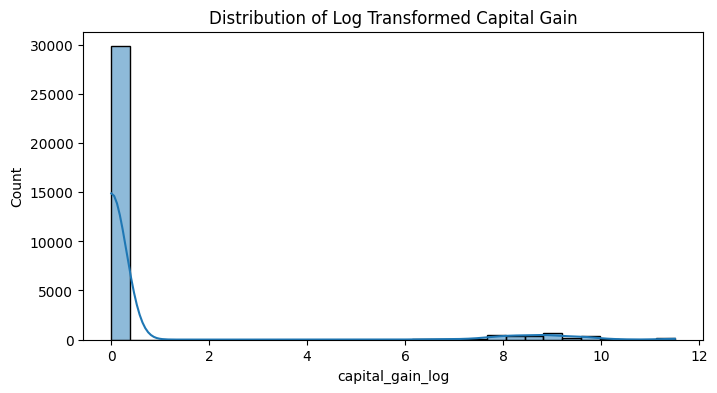

In [26]:
# Check distribution after transformation
plt.figure(figsize=(8,4))
sns.histplot(data['capital_gain_log'], bins=30, kde=True)
plt.title("Distribution of Log Transformed Capital Gain")
plt.show()

In [27]:
# Step 6: Feature Selection (Outlier Removal)
# Isolation Forest for outlier detection
iso = IsolationForest(contamination=0.02, random_state=42)
yhat = iso.fit_predict(data[num_cols])


In [28]:
# Identify outliers
mask = yhat != -1
data_cleaned = data[mask]

print("\nShape before removing outliers:", data.shape)
print("Shape after removing outliers:", data_cleaned.shape)


Shape before removing outliers: (32561, 22)
Shape after removing outliers: (31909, 22)


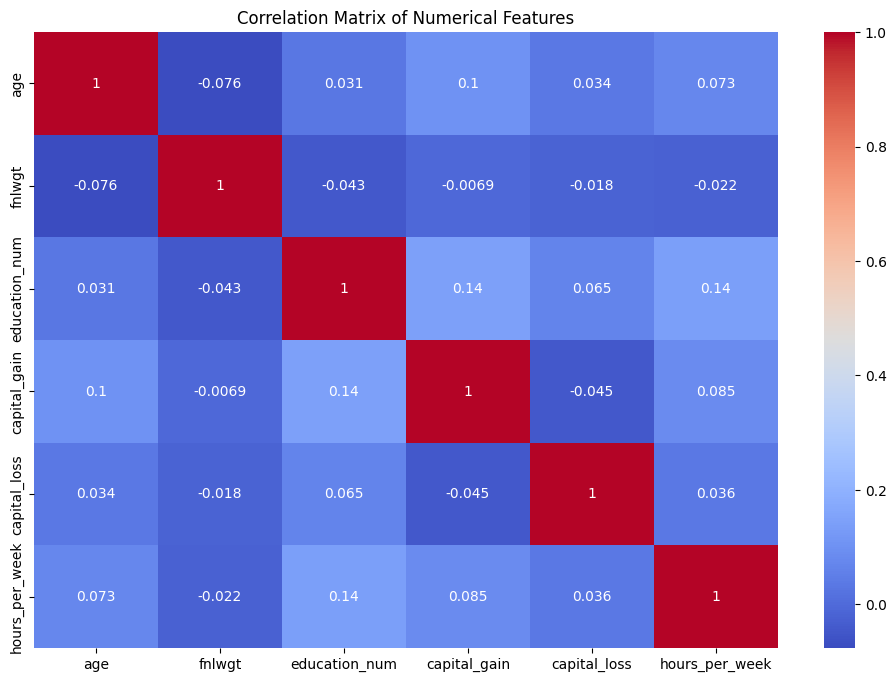

In [29]:
# Step 7: Correlation Matrix (Instead of PPS)
plt.figure(figsize=(12,8))
sns.heatmap(data_cleaned[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# PPS NOTE
PPS (Predictive Power Score) is not included because it is not working on this system.
Normally, PPS is used to capture both linear and non-linear relationships between features.

# Summary
1️ Data Exploration and Preprocessing

Loaded the dataset using pandas and explored basic statistics, datatypes, and missing values.

Handled missing values:

Replaced "?" with NaN for accurate detection.

Filled categorical missing values with mode and numerical ones with mean.

Removed whitespaces in categorical columns for data cleanliness.

✅ Result: Dataset is now clean and ready for processing.

2️ Scaling Techniques

Selected all numerical features.

Applied:

Standard Scaling: Centers data around mean = 0, std = 1 → best for normally distributed data (e.g., Linear Models, SVM).

Min-Max Scaling: Transforms data to [0, 1] → preferred for algorithms like Neural Networks or KNN that rely on distance metrics.

✅ Result: Numerical data normalized for better model performance.

3️ Encoding Techniques

Identified all categorical columns.

One-Hot Encoding applied to features with < 5 unique values.

Label Encoding applied to features with > 5 unique values.

Discussion:

One-Hot Encoding: Prevents introducing artificial order but increases dimensionality.

Label Encoding: Space-efficient but can introduce false ordinal relationships.

✅ Result: All categorical data converted to numeric form.

4️ Feature Engineering

Created new features to improve model interpretability and performance:

hours_per_week_category — groups individuals into “Low”, “Medium”, “High”, “Very High” based on weekly work hours.

age_group — categorizes ages into “Young”, “Adult”, “Middle-Aged”, and “Senior”.

Additionally:

Applied log transformation on capital-gain to reduce skewness and normalize distribution.

✅ Result: Enhanced features and better-balanced numerical data for learning.

5️ Feature Selection

Used Isolation Forest to detect and remove outliers:

Approximately 2% of samples identified as outliers and removed.

Outliers can distort scaling and bias models; hence, removing them improves training stability.

✅ Result: Cleaner dataset with reduced noise.

6️ Correlation Analysis

Visualized correlation matrix among numerical features using a heatmap.

Found relationships between features (e.g., education-num vs. hours-per-week).

⚠️ PPS (Predictive Power Score) was skipped as it was not functional on the system.

📘 Final Outcome

After preprocessing, encoding, scaling, feature creation, and outlier removal:

The dataset is fully cleaned, normalized, and enhanced for model building.

The workflow demonstrates a complete real-world data preprocessing pipeline essential before applying machine learning algorithms.